In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import sourse_new
plt.rcParams["font.size"] = 14

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
import

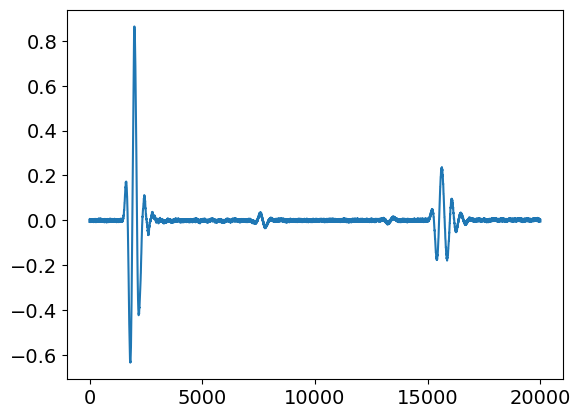

In [2]:
len(np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv"))
len(sourse_new.import_data(0,0)[0])
plt.plot(sourse_new.import_data(0,0)[0])

In [3]:
0.7e-6/sourse_new.dt

982.0027324927154

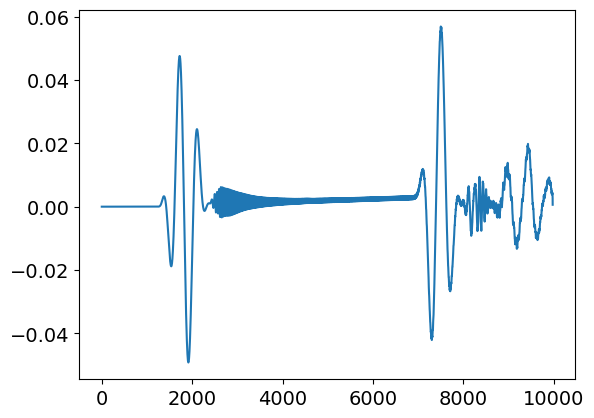

In [4]:
plt.plot(sourse_new.interpolate_sim_one(np.load(fr"C:\Users\manat\project2\surface_wave_2d\T3\T3_series_middle_point_pitch_200_depth{0}.npy")))

In [5]:
depth_list = [0, 40, 100, 170, 200]
surface_wave = np.zeros((6, 4096))
for i in range(len(depth_list)):
    surface_wave[i] = sourse_new.interpolate_sim_one(np.load(fr"C:\Users\manat\project2\surface_wave_2d\T3\T3_series_middle_point_pitch_200_depth{depth_list[i]}.npy"))[982:982+4096]
    surface_wave[i] = -surface_wave[i]


In [6]:
exp_wave = np.zeros((6, 20000))
for i in range(len(depth_list)):
    if i == 0:
        exp_wave[i] = sourse_new.import_data(0,0)[0]
    else:
        exp_wave[i] = sourse_new.import_data(200, int(depth_list[i]/10))[0]

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_50.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_51.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_52.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_5

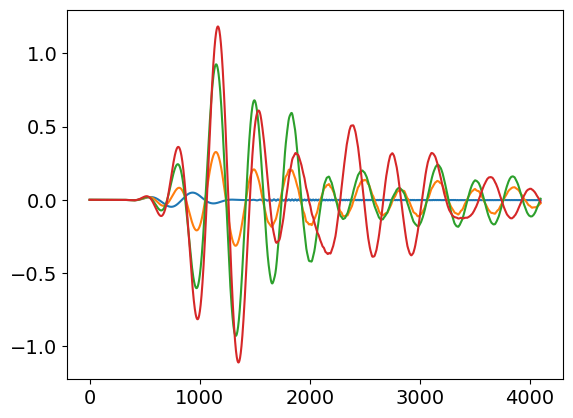

In [7]:
for i in range(4):
    plt.plot(surface_wave[i])

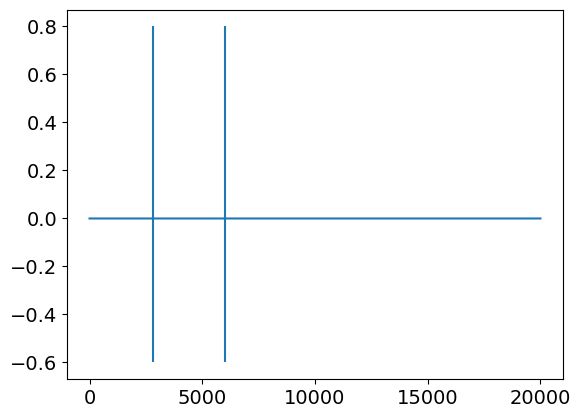

In [8]:
plt.plot(exp_wave[5])
plt.vlines(1800+sourse_new.left, -0.6, 0.8)
plt.vlines(5000+sourse_new.left, -0.6, 0.8)

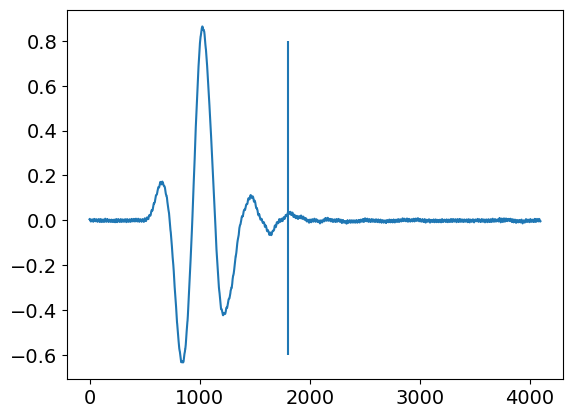

In [9]:
plt.plot(sourse_new.kiritori2(exp_wave[0], sourse_new.left, sourse_new.right))
plt.vlines(1800, -0.6, 0.8)

In [10]:
sim_waves = np.zeros((5, 19586))
for i in range(len(depth_list)):
    sim_waves[i] = np.loadtxt(fr"C:\Users\manat\project2\data_all\cupy_pitch200_depth{int(depth_list[i]/10)}.csv") 

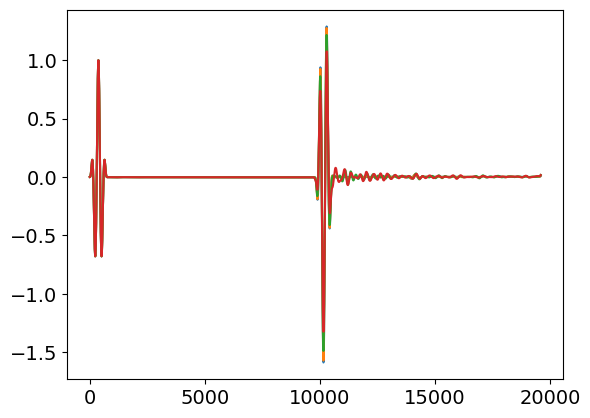

In [11]:
for i in range(4):
    plt.plot(sim_waves[i])

In [12]:
sim_waves = np.zeros((5, 19586))
for i in range(len(depth_list)):
    sim_waves[i] = np.loadtxt(fr"C:\Users\manat\project2\data_all\cupy_pitch200_depth{int(depth_list[i]/10)}.csv") 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


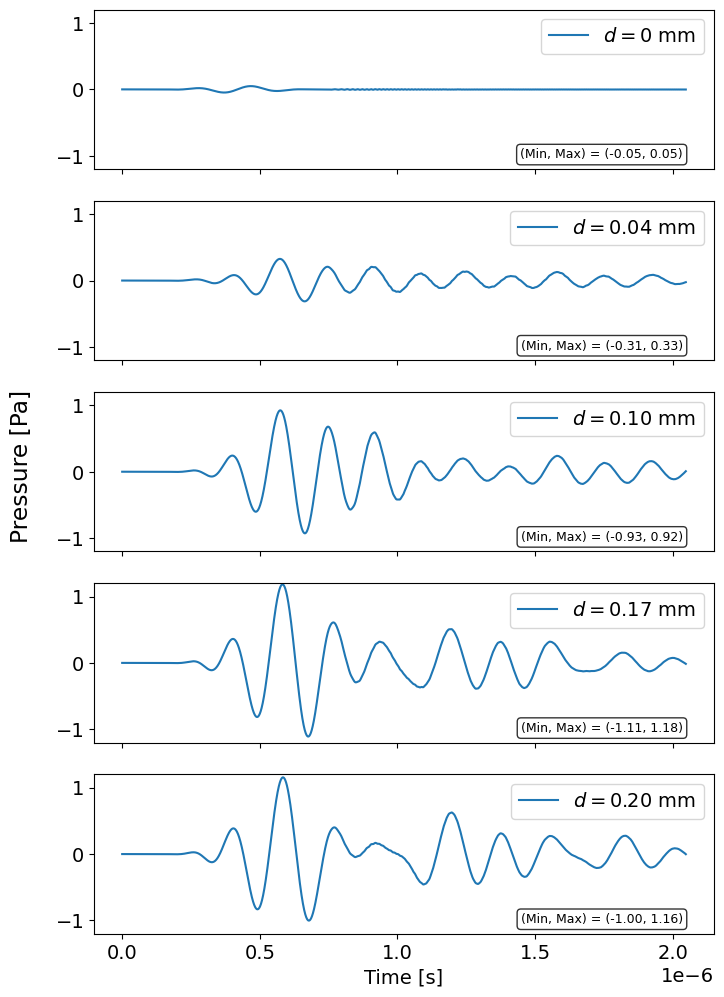

In [13]:
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time = np.arange(0, 4096*sourse_new.exp_dt, sourse_new.exp_dt)
labels = ["$d=0$ mm","$d=0.04$ mm","$d=0.10$ mm","$d=0.17$ mm","$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(surface_wave[i])
    max_val = np.max(surface_wave[i])
    axes[i].plot(time, surface_wave[i], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-1.2, 1.2)
    # 右下に最大値と最小値を表示
    axes[i].text(0.95, 0.05, f'(Min, Max) = ({min_val:.2f}, {max_val:.2f})', 
                 transform=axes[i].transAxes, 
                 verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                 fontsize=9)



plt.xlabel("Time [s]")
fig.supylabel("Pressure [Pa]")
plt.savefig("Figure11b.eps", format="eps")

# グラフを表示
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


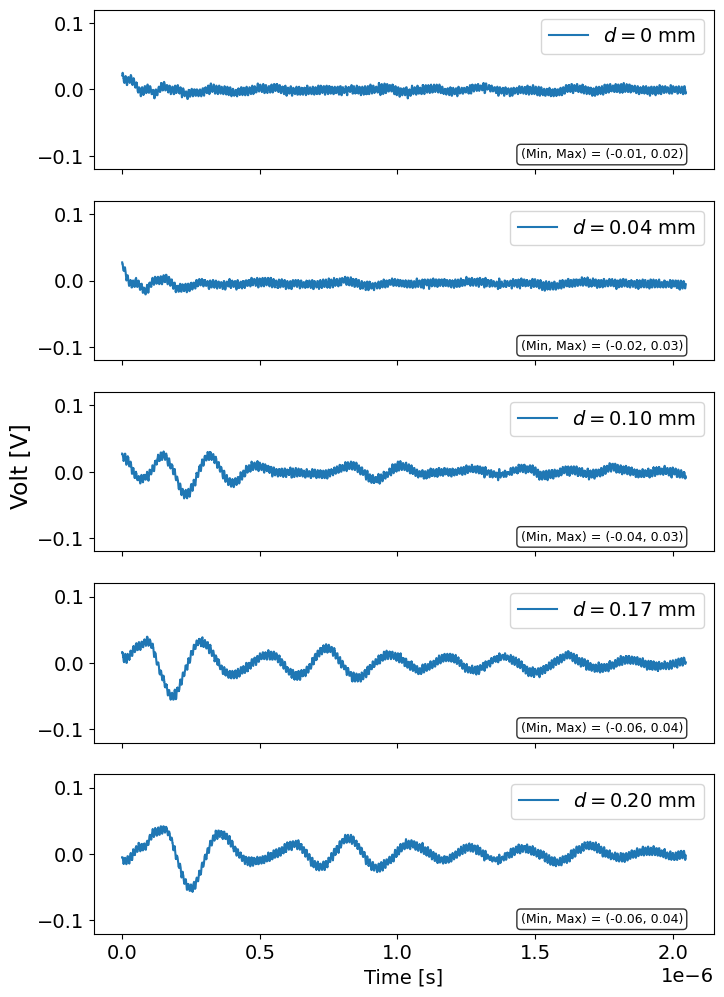

In [14]:
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time_exp = np.arange(0, len(exp_wave[0][1800+sourse_new.left:4096+1800+sourse_new.left])*sourse_new.exp_dt, sourse_new.exp_dt)
labels = ["$d=0$ mm","$d=0.04$ mm","$d=0.10$ mm","$d=0.17$ mm","$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left])
    max_val = np.max(exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left])
    axes[i].plot(time_exp, exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-0.12, 0.12)
    # 右下に最大値と最小値を表示
    axes[i].text(0.95, 0.05, f'(Min, Max) = ({min_val:.2f}, {max_val:.2f})', 
                 transform=axes[i].transAxes, 
                 verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                 fontsize=9)


plt.xlabel("Time [s]")
fig.supylabel("Volt [V]")

plt.savefig("Figure11a.eps", format="eps")

# グラフを表示
plt.show()